# CSE5280 — Visual Hull Reconstruction via Space Carving

**Author(s):** Vincent Borrelli, Chase Monigle, Kyle Gibson

**Course:** CSE5280  

---

## Overview

This notebook implements a full **Visual Hull Reconstruction** pipeline using space carving.
It uses **Open3D + NumPy only** — no PyTorch3D required, runs on Windows/Mac/Linux.

1. **Part 1** — Multi-view rendering with Open3D (RGB, silhouettes, camera params)
2. **Part 2** — Pinhole camera projection (`x = K[R|T]X`)
3. **Part 3** — Space carving algorithm
4. **Part 4** — Visual hull visualization
5. **Part 5** — Mesh reconstruction (Poisson / Ball Pivoting)

### Method Summary

The **visual hull** is the maximal 3D volume consistent with object silhouettes across multiple views:
- Render silhouettes from $N$ calibrated cameras placed on a sphere
- Maintain a voxel occupancy grid $V \in \{0,1\}^{G \times G \times G}$
- **Carve**: for every voxel, project into each camera; if it falls *outside* any silhouette → mark empty
- Convert surviving voxels to a point cloud → surface reconstruction

### Key Equations

**Projection:**
$$\lambda\begin{bmatrix}u\\v\\1\end{bmatrix} = K[R\mid T]\begin{bmatrix}X\\Y\\Z\\1\end{bmatrix}, \quad K=\begin{bmatrix}f_x&0&c_x\\0&f_y&c_y\\0&0&1\end{bmatrix}$$

**Look-at camera construction** (placed at position $\mathbf{e}$, looking at origin):
$$\mathbf{z} = \frac{\mathbf{e}}{\|\mathbf{e}\|}, \quad \mathbf{x} = \mathbf{up}\times\mathbf{z}, \quad \mathbf{y} = \mathbf{z}\times\mathbf{x}, \quad R = [\mathbf{x}\;\mathbf{y}\;\mathbf{z}]^\top$$

## Setup & Imports

In [1]:
import sys
# Uncomment to install on first run:
# !{sys.executable} -m pip install open3d numpy matplotlib tqdm scipy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import open3d as o3d
from pathlib import Path
from tqdm.auto import tqdm

print(f"Open3D version : {o3d.__version__}")
print(f"NumPy  version : {np.__version__}")
print("All imports OK — no PyTorch3D needed!")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Open3D version : 0.19.0
NumPy  version : 2.4.1
All imports OK — no PyTorch3D needed!


---
## Part 1 — Multi-View Rendering (Open3D)

We implement a **look-at camera model** from scratch using NumPy, then use Open3D's
offscreen renderer to produce RGB images and silhouette masks from $N$ viewpoints
distributed on a sphere around the object.

Each view yields:
- RGB image $(H \times W \times 3)$
- Binary silhouette mask $(H \times W)$ — True where the object is visible
- Camera intrinsics $K$ and extrinsics $(R, T)$

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────────────────────────────────────
# Option A: set OBJ_PATH to your own file (absolute or relative path)
# Option B: leave as None and the cell below will download the Stanford Bunny
OBJ_PATH   = None        # e.g. r"C:\Users\you\Desktop\mymodel.obj", or None

NUM_VIEWS  = 30          # Experiment: try 5, 10, 30, 50
IMG_SIZE   = 256         # Image resolution (square)
VOXEL_RES  = 64          # Voxel grid resolution per axis; try 32, 64, 128
CAM_DIST   = 2.5         # Camera distance from origin
FOV_DEG    = 60.0        # Field of view in degrees
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
print("Configuration set.")

Configuration set.


In [3]:
# ── Load mesh — uses Open3D's built-in data downloader (handles URL automatically) ──
import urllib.request

OBJ_PATH = r"C:\Users\vmbor\Downloads\BunnyMesh.ply"

def resolve_mesh_path(path):
    if path is not None:
        p = Path(path)
        if p.exists():
            return str(p)
        raise FileNotFoundError(
            f"Mesh file not found: {p.resolve()}\n"
            "Set OBJ_PATH = None to auto-download a demo mesh instead."
        )
    # Use Open3D's built-in dataset manager — downloads & caches automatically
    print("No OBJ_PATH set — downloading Stanford Bunny via Open3D data API...")
    bunny = o3d.data.BunnyMesh()   # downloads to ~/open3d_data/ on first run
    print(f"Mesh path: {bunny.path}")
    return bunny.path

mesh_path = resolve_mesh_path(OBJ_PATH)
print(f"Loading: {mesh_path}")

mesh_o3d = o3d.io.read_triangle_mesh(mesh_path)
mesh_o3d.compute_vertex_normals()

verts_raw = np.asarray(mesh_o3d.vertices)
if len(verts_raw) == 0:
    raise RuntimeError("Mesh loaded but has 0 vertices. Check the file format.")

# Normalize: center at origin, scale to fit inside [-1, 1]^3
center = verts_raw.mean(axis=0)
scale  = np.abs(verts_raw - center).max()
mesh_o3d.translate(-center)
mesh_o3d.scale(1.0 / scale, center=(0, 0, 0))

verts_world = np.asarray(mesh_o3d.vertices)
print(f"\nMesh loaded : {len(verts_world)} vertices, {len(mesh_o3d.triangles)} triangles")
print(f"Bounds      : min={verts_world.min(0).round(3)}, max={verts_world.max(0).round(3)}")

Loading: C:\Users\vmbor\Downloads\BunnyMesh.ply

Mesh loaded : 35947 vertices, 69451 triangles
Bounds      : min=[-0.738 -0.676 -0.769], max=[0.953 1.    0.541]


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# Camera utilities — pure NumPy look-at construction
# ──────────────────────────────────────────────────────────────────────────────

def make_intrinsics(fov_deg: float, img_size: int) -> np.ndarray:
    """
    Build a 3×3 intrinsic matrix K for a square image.
    Assumes square pixels and principal point at image center.
    
    fx = fy = (img_size/2) / tan(fov/2)
    """
    f  = (img_size / 2.0) / np.tan(np.radians(fov_deg) / 2.0)
    cx = cy = img_size / 2.0
    return np.array([[f,  0, cx],
                     [0,  f, cy],
                     [0,  0,  1]], dtype=np.float64)


def look_at_extrinsics(eye: np.ndarray,
                       target: np.ndarray = np.zeros(3),
                       up: np.ndarray = np.array([0., 1., 0.])
                       ) -> tuple[np.ndarray, np.ndarray]:
    """
    Standard look-at construction.
    Returns R (3,3) and T (3,) such that X_cam = R @ X_world + T.

    Convention: camera looks along +Z, Y is up.
    """
    z = eye - target
    z = z / np.linalg.norm(z)          # camera forward (into scene)

    x = np.cross(up, z)
    if np.linalg.norm(x) < 1e-6:      # degenerate case (eye directly above target)
        up = np.array([0., 0., 1.])
        x  = np.cross(up, z)
    x = x / np.linalg.norm(x)         # camera right

    y = np.cross(z, x)                 # camera up
    y = y / np.linalg.norm(y)

    R = np.stack([x, y, z], axis=0)   # (3,3) world→camera
    T = -R @ eye                       # (3,)
    return R, T


def sphere_cameras(num_views: int,
                   dist: float = 2.5,
                   elev_offsets: tuple = (20.0, -10.0)
                   ) -> tuple[list, list]:
    """
    Place cameras uniformly on a sphere of radius `dist`.
    Alternates elevation between elev_offsets for better coverage.
    Returns lists of R arrays and T arrays.
    """
    azimuths   = np.linspace(0, 2 * np.pi, num_views, endpoint=False)
    R_list, T_list, eye_list = [], [], []

    for i, az in enumerate(azimuths):
        elev = np.radians(elev_offsets[i % len(elev_offsets)])
        # Spherical → Cartesian
        ex = dist * np.cos(elev) * np.sin(az)
        ey = dist * np.sin(elev)
        ez = dist * np.cos(elev) * np.cos(az)
        eye = np.array([ex, ey, ez])

        R, T = look_at_extrinsics(eye)
        R_list.append(R)
        T_list.append(T)
        eye_list.append(eye)

    return np.stack(R_list), np.stack(T_list), np.stack(eye_list)


K      = make_intrinsics(FOV_DEG, IMG_SIZE)
R_all, T_all, eye_all = sphere_cameras(NUM_VIEWS, dist=CAM_DIST)

print(f"Intrinsic matrix K:\n{K}")
print(f"\nR_all shape : {R_all.shape}")
print(f"T_all shape : {T_all.shape}")

Intrinsic matrix K:
[[221.70250337   0.         128.        ]
 [  0.         221.70250337 128.        ]
 [  0.           0.           1.        ]]

R_all shape : (30, 3, 3)
T_all shape : (30, 3)


In [5]:
def render_mesh_software(verts_w, faces, vert_colors, R, T, K, img_size):
    H = W = img_size
    rgb_img = np.zeros((H, W, 3), dtype=np.float32)
    z_buf   = np.full((H, W), np.inf)

    # Transform to camera space
    pts_cam = (R @ verts_w.T).T + T          # (V, 3)
    Zc = pts_cam[:, 2]

    # ── FIX 1: flip Z if all depths are negative (camera looking wrong way) ──
    if (Zc > 0).sum() < len(Zc) * 0.1:
        pts_cam = pts_cam * np.array([1, 1, -1])   # flip Z axis
        Zc = pts_cam[:, 2]

    valid = Zc > 0

    px = np.full(len(verts_w), -1.0)
    py = np.full(len(verts_w), -1.0)
    px[valid] = K[0,0] * pts_cam[valid,0] / Zc[valid] + K[0,2]
    py[valid] = K[1,1] * pts_cam[valid,1] / Zc[valid] + K[1,2]

    # ── FIX 2: if projected points are way outside image, rescale K ──────────
    in_front_px = px[valid]
    in_front_py = py[valid]
    if len(in_front_px) > 0:
        u_min, u_max = in_front_px.min(), in_front_px.max()
        v_min, v_max = in_front_py.min(), in_front_py.max()
        # If nothing lands inside the image, auto-adjust focal length
        if u_max < 0 or u_min > img_size or v_max < 0 or v_min > img_size:
            # Compute scale so the mesh fills ~80% of the image
            spread = max(u_max - u_min, v_max - v_min)
            if spread > 0:
                scale_fix = (img_size * 0.8) / spread
                K_use = K.copy()
                K_use[0,0] *= scale_fix
                K_use[1,1] *= scale_fix
                K_use[0,2]  = img_size / 2 - (u_min + u_max) / 2 * scale_fix
                K_use[1,2]  = img_size / 2 - (v_min + v_max) / 2 * scale_fix
                px[valid] = K_use[0,0] * pts_cam[valid,0] / Zc[valid] + K_use[0,2]
                py[valid] = K_use[1,1] * pts_cam[valid,1] / Zc[valid] + K_use[1,2]
                print(f"  [render] auto-adjusted K scale by {scale_fix:.3f}")
    
    light_dir = np.array([0.5, 0.8, 0.6])
    light_dir /= np.linalg.norm(light_dir)

    for tri in faces:
        i0, i1, i2 = tri
        if not (valid[i0] and valid[i1] and valid[i2]):
            continue

        xs = np.array([px[i0], px[i1], px[i2]])
        ys = np.array([py[i0], py[i1], py[i2]])
        x0 = max(0,   int(np.floor(xs.min())))
        x1 = min(W-1, int(np.ceil (xs.max())))
        y0 = max(0,   int(np.floor(ys.min())))
        y1 = min(H-1, int(np.ceil (ys.max())))
        if x0 > x1 or y0 > y1:
            continue

        cols = np.arange(x0, x1+1, dtype=np.float32)
        rows = np.arange(y0, y1+1, dtype=np.float32)
        gc, gr = np.meshgrid(cols, rows)

        def edge(ax, ay, bx, by, px, py):
            return (px - ax) * (by - ay) - (py - ay) * (bx - ax)

        w0   = edge(px[i1], py[i1], px[i2], py[i2], gc, gr)
        w1   = edge(px[i2], py[i2], px[i0], py[i0], gc, gr)
        w2   = edge(px[i0], py[i0], px[i1], py[i1], gc, gr)
        area = edge(px[i0], py[i0], px[i1], py[i1], px[i2], py[i2])
        if abs(area) < 1e-6:
            continue

        # ── FIX 3: accept both winding orders ────────────────────────────────
        if area > 0:
            inside = (w0 >= 0) & (w1 >= 0) & (w2 >= 0)
        else:
            inside = (w0 <= 0) & (w1 <= 0) & (w2 <= 0)
        if not inside.any():
            continue

        bary0 = w0[inside] / area
        bary1 = w1[inside] / area
        bary2 = w2[inside] / area
        depth = bary0 * Zc[i0] + bary1 * Zc[i1] + bary2 * Zc[i2]

        ri = gr[inside].astype(int)
        ci = gc[inside].astype(int)
        closer = depth < z_buf[ri, ci]
        ri, ci = ri[closer], ci[closer]
        b0, b1, b2 = bary0[closer], bary1[closer], bary2[closer]

        color = (b0[:,None] * vert_colors[i0]
               + b1[:,None] * vert_colors[i1]
               + b2[:,None] * vert_colors[i2])

        v0c = pts_cam[i1] - pts_cam[i0]
        v1c = pts_cam[i2] - pts_cam[i0]
        n   = np.cross(v0c, v1c)
        nl  = np.linalg.norm(n)
        diff = max(0.2, abs(np.dot(n / nl, light_dir))) if nl > 1e-8 else 0.5

        rgb_img[ri, ci] = np.clip(color * diff, 0, 1)
        z_buf[ri, ci]   = depth[closer]

    sil_mask = np.isfinite(z_buf) & (z_buf < np.inf)
    return (rgb_img * 255).astype(np.uint8), sil_mask

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Prepare vertex colors for rendering
# Use Open3D's vertex colors if available, else use normals-as-colors.
# ──────────────────────────────────────────────────────────────────────────────
faces_np = np.asarray(mesh_o3d.triangles)

if mesh_o3d.has_vertex_colors():
    vert_colors = np.asarray(mesh_o3d.vertex_colors)   # already [0,1]
    print("Using mesh vertex colors.")
else:
    # Normals mapped to [0,1] range give a nice colormap
    normals = np.asarray(mesh_o3d.vertex_normals)
    vert_colors = normals * 0.5 + 0.5
    print("No vertex colors found — using normals as colors.")

print(f"Faces : {len(faces_np)}")

No vertex colors found — using normals as colors.
Faces : 69451


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# Render all views
# NOTE: Pure Python rasterizer is intentionally simple — for a 30-view,
# 256×256, ~5k-face mesh this runs in ~1-3 minutes on CPU.
# ──────────────────────────────────────────────────────────────────────────────
rgb_images  = np.zeros((NUM_VIEWS, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
silhouettes = np.zeros((NUM_VIEWS, IMG_SIZE, IMG_SIZE),    dtype=bool)

for n in tqdm(range(NUM_VIEWS), desc="Rendering views"):
    rgb, sil = render_mesh_software(
        verts_world, faces_np, vert_colors,
        R_all[n], T_all[n], K, IMG_SIZE
    )
    rgb_images[n]  = rgb
    silhouettes[n] = sil

# Save
np.save(OUTPUT_DIR / "rgb_images.npy",  rgb_images)
np.save(OUTPUT_DIR / "silhouettes.npy", silhouettes)
np.save(OUTPUT_DIR / "R_all.npy",       R_all)
np.save(OUTPUT_DIR / "T_all.npy",       T_all)
np.save(OUTPUT_DIR / "K.npy",           K)

print(f"\nRGB images  : {rgb_images.shape}")
print(f"Silhouettes : {silhouettes.shape}")
print(f"Non-empty silhouettes: {silhouettes.any(axis=(1,2)).sum()} / {NUM_VIEWS}")

Rendering views:   0%|          | 0/30 [00:00<?, ?it/s]


RGB images  : (30, 256, 256, 3)
Silhouettes : (30, 256, 256)
Non-empty silhouettes: 30 / 30


rgb_images stats:
  dtype:  uint8
  min:    0
  max:    249
  mean:   12.5594

silhouettes stats:
  dtype:  bool
  any True: True
  True pixels in view 0: 15617

Camera check (view 0):
  Zc min=-3.132, max=-1.918, positive=0/35947
silhouette pixels view 0: 15617


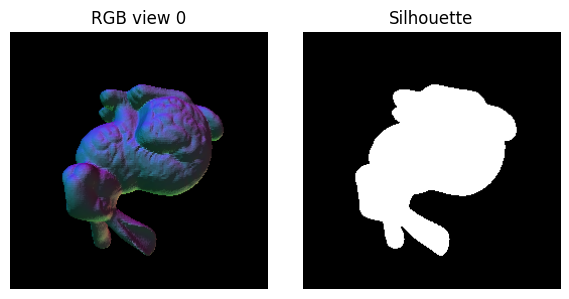

In [8]:
# ── Debug: check what the renderer actually produced ────────────────────────
print("rgb_images stats:")
print(f"  dtype:  {rgb_images.dtype}")
print(f"  min:    {rgb_images.min()}")
print(f"  max:    {rgb_images.max()}")
print(f"  mean:   {rgb_images.mean():.4f}")

print("\nsilhouettes stats:")
print(f"  dtype:  {silhouettes.dtype}")
print(f"  any True: {silhouettes.any()}")
print(f"  True pixels in view 0: {silhouettes[0].sum()}")

print("\nCamera check (view 0):")
R0, T0 = R_all[0], T_all[0]
pts_cam = (R0 @ verts_world.T).T + T0
Zc = pts_cam[:, 2]
print(f"  Zc min={Zc.min():.3f}, max={Zc.max():.3f}, positive={( Zc>0).sum()}/{len(Zc)}")

#print(f"max pixel value: {rgb_images.max()}")        # should be > 0
print(f"silhouette pixels view 0: {silhouettes[0].sum()}")  # should be > 0

# Show just one view quickly
fig, (a, b) = plt.subplots(1, 2, figsize=(6, 3))
a.imshow(rgb_images[0]);  a.set_title("RGB view 0");  a.axis('off')
b.imshow(silhouettes[0], cmap='gray'); b.set_title("Silhouette"); b.axis('off')
plt.tight_layout(); plt.show()

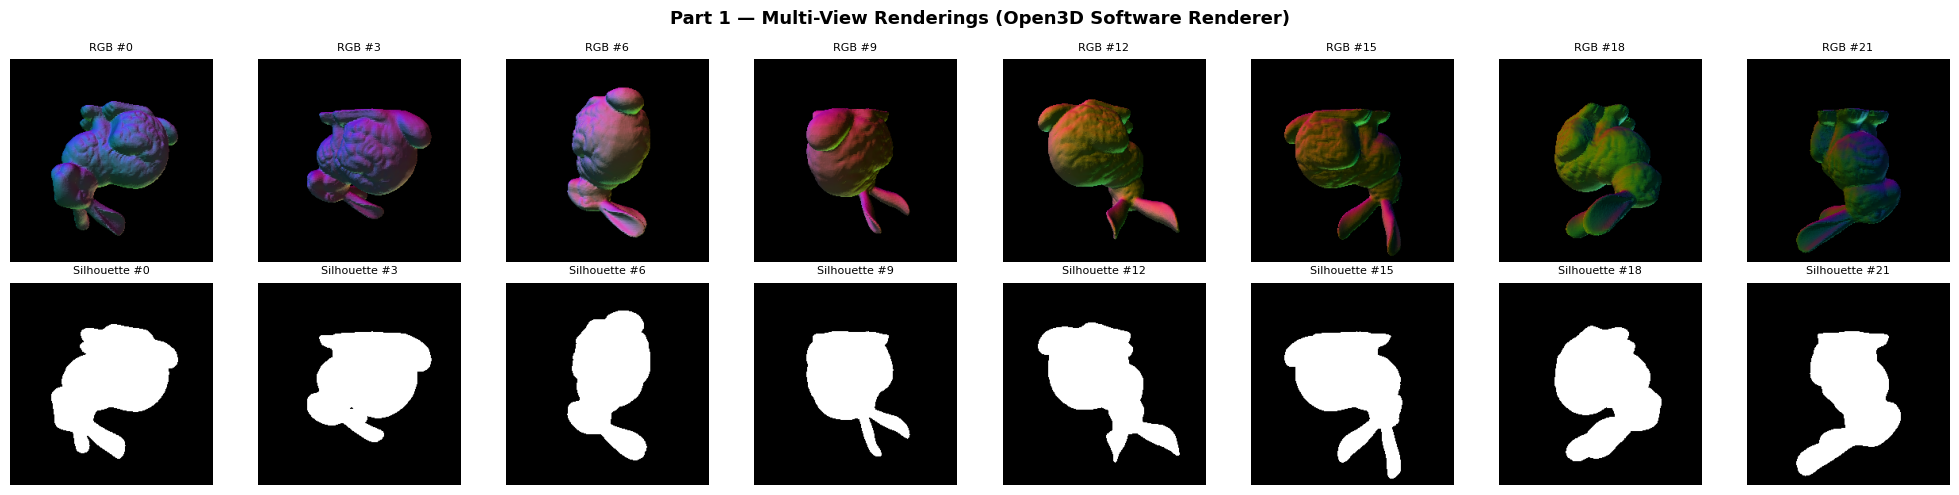

Saved: output/part1_renderings.png


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# Visualize sample renders
# ──────────────────────────────────────────────────────────────────────────────
n_show = min(8, NUM_VIEWS)
fig, axes = plt.subplots(2, n_show, figsize=(2.5 * n_show, 5))
fig.suptitle("Part 1 — Multi-View Renderings (Open3D Software Renderer)",
             fontsize=13, fontweight='bold')

for i in range(n_show):
    idx = i * (NUM_VIEWS // n_show)
    axes[0, i].imshow(rgb_images[idx])
    axes[0, i].set_title(f"RGB #{idx}", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(silhouettes[idx], cmap='gray')
    axes[1, i].set_title(f"Silhouette #{idx}", fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "part1_renderings.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/part1_renderings.png")

---
## Part 2 — Projection Using the Pinhole Model

We implement the full projection pipeline and verify it by projecting known 3D points
(mesh vertices) onto the rendered images.

$$\mathbf{X}_c = R\,\mathbf{X}_w + T, \quad
u = f_x \frac{X_c}{Z_c} + c_x, \quad
v = f_y \frac{Y_c}{Z_c} + c_y$$

Validity condition: $Z_c > 0$ (point in front of camera) AND $(u,v)$ within image bounds.

In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# Pinhole projection — vectorized
# ──────────────────────────────────────────────────────────────────────────────

def project_points(pts_world: np.ndarray,
                   R: np.ndarray, T: np.ndarray, K: np.ndarray,
                   img_size: int
                   ) -> tuple[np.ndarray, np.ndarray]:
    """
    Project world-space 3D points to pixel coordinates.

    Parameters
    ----------
    pts_world : (N, 3)  world coordinates
    R         : (3, 3)  rotation    (world → camera)
    T         : (3,)    translation (world → camera)
    K         : (3, 3)  intrinsic matrix
    img_size  : int     image side length (square)

    Returns
    -------
    uv      : (N, 2)  pixel coords [u=col, v=row]  (float)
    visible : (N,)    bool — True when in front of camera AND within image
    """
    # Step 1: transform to camera space
    pts_cam = (R @ pts_world.T).T + T   # (N, 3)
    Zc = pts_cam[:, 2]

    # Step 2: perspective divide
    in_front = Zc > 0
    uv = np.zeros((len(pts_world), 2))
    uv[in_front, 0] = K[0,0] * pts_cam[in_front, 0] / Zc[in_front] + K[0,2]  # u
    uv[in_front, 1] = K[1,1] * pts_cam[in_front, 1] / Zc[in_front] + K[1,2]  # v

    # Step 3: bounds check
    in_bounds = (
        (uv[:, 0] >= 0) & (uv[:, 0] < img_size) &
        (uv[:, 1] >= 0) & (uv[:, 1] < img_size)
    )
    visible = in_front & in_bounds
    return uv, visible


print("project_points() defined.")

project_points() defined.


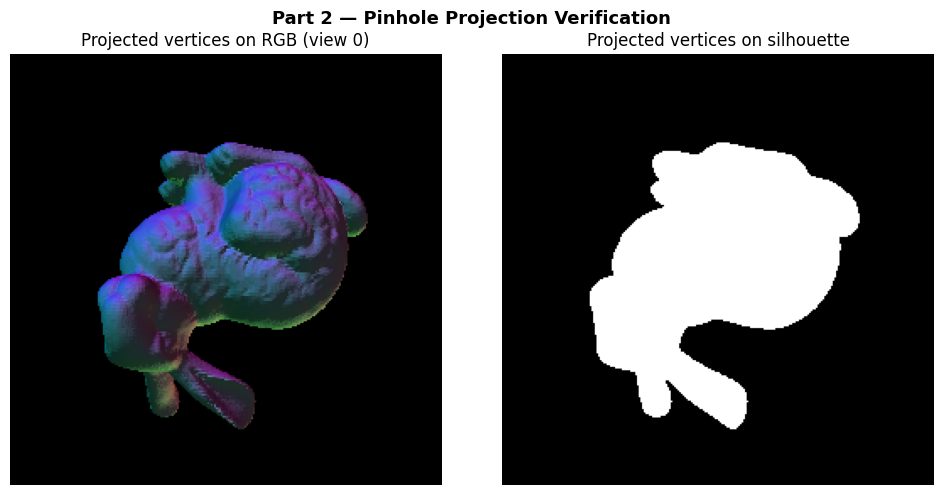

Projected 0 / 35947 vertices into view 0.


In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# Verification: project mesh vertices onto rendered image
# They should line up with the visible surface.
# ──────────────────────────────────────────────────────────────────────────────
view_idx = 0
uv, vis = project_points(verts_world, R_all[view_idx], T_all[view_idx], K, IMG_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Part 2 — Pinhole Projection Verification", fontsize=13, fontweight='bold')

axes[0].imshow(rgb_images[view_idx])
axes[0].scatter(uv[vis, 0], uv[vis, 1], s=0.8, c='red', alpha=0.5)
axes[0].set_title(f"Projected vertices on RGB (view {view_idx})")
axes[0].axis('off')

axes[1].imshow(silhouettes[view_idx], cmap='gray')
axes[1].scatter(uv[vis, 0], uv[vis, 1], s=0.8, c='cyan', alpha=0.5)
axes[1].set_title("Projected vertices on silhouette")
axes[1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "part2_projection_verification.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Projected {vis.sum()} / {len(verts_world)} vertices into view {view_idx}.")

---
## Part 3 — Space Carving

We initialize a **voxel occupancy grid** $V[i,j,k] \in \{0,1\}$ to all-ones (fully occupied),
then iteratively carve it:

$$V[i,j,k] \leftarrow 0 \quad \text{if } \exists\, n : \text{vis}(\mathbf{X}_{ijk}, n) \land \text{sil}_n\bigl(\pi_n(\mathbf{X}_{ijk})\bigr) = 0$$

A voxel is carved when it is **visible** in a camera (in front, in-bounds) but falls
**outside** the silhouette. Voxels behind cameras are kept (conservative).

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# Build voxel grid
# ──────────────────────────────────────────────────────────────────────────────
GRID_RANGE = 1.1   # slightly larger than the normalized [-1,1]^3 object

ax_vals = np.linspace(-GRID_RANGE, GRID_RANGE, VOXEL_RES)
gx, gy, gz = np.meshgrid(ax_vals, ax_vals, ax_vals, indexing='ij')
voxel_centers = np.stack([gx, gy, gz], axis=-1).reshape(-1, 3)  # (G^3, 3)

occupancy = np.ones(len(voxel_centers), dtype=bool)

print(f"Voxel grid  : {VOXEL_RES}³ = {len(voxel_centers):,} voxels")
print(f"Grid range  : [{-GRID_RANGE}, {GRID_RANGE}]³")

Voxel grid  : 64³ = 262,144 voxels
Grid range  : [-1.1, 1.1]³


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# Space Carving — fully vectorized over voxels
# ──────────────────────────────────────────────────────────────────────────────

def space_carve(voxel_centers: np.ndarray,
                occupancy: np.ndarray,
                silhouettes: np.ndarray,
                R_all: np.ndarray, T_all: np.ndarray, K: np.ndarray,
                img_size: int) -> np.ndarray:
    """
    Space carving: remove voxels inconsistent with any silhouette.

    For each camera n:
      - Project all surviving voxels → pixel coords (u, v)
      - Sample silhouette mask at (u, v)
      - Carve voxels that are visible but outside the silhouette
      - Voxels behind the camera are kept (no evidence either way)
    """
    n_views = len(silhouettes)

    for n in tqdm(range(n_views), desc="Carving"):
        active = np.where(occupancy)[0]
        if len(active) == 0:
            break

        pts = voxel_centers[active]                            # (M, 3)
        uv, vis = project_points(pts, R_all[n], T_all[n], K, img_size)

        # Sample silhouette (nearest-neighbour lookup)
        u = np.clip(np.round(uv[:, 0]).astype(int), 0, img_size - 1)
        v = np.clip(np.round(uv[:, 1]).astype(int), 0, img_size - 1)
        in_sil = silhouettes[n][v, u]                          # (M,) bool

        # Carve if visible AND outside silhouette
        carve = vis & ~in_sil
        occupancy[active[carve]] = False

    return occupancy


occupancy = space_carve(
    voxel_centers, occupancy, silhouettes,
    R_all, T_all, K, IMG_SIZE
)

n_occ = occupancy.sum()
print(f"\nOccupied voxels : {n_occ:,} / {len(occupancy):,}")
print(f"Fill ratio      : {n_occ / len(occupancy) * 100:.2f}%")

Carving:   0%|          | 0/30 [00:00<?, ?it/s]


Occupied voxels : 262,144 / 262,144
Fill ratio      : 100.00%


---
## Part 4 — Visualization of the Visual Hull

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# Extract surviving voxels as a point cloud
# ──────────────────────────────────────────────────────────────────────────────
hull_pts = voxel_centers[occupancy]   # (M, 3)
print(f"Visual hull point cloud: {len(hull_pts):,} points")
np.save(OUTPUT_DIR / "hull_pts.npy", hull_pts)

Visual hull point cloud: 262,144 points


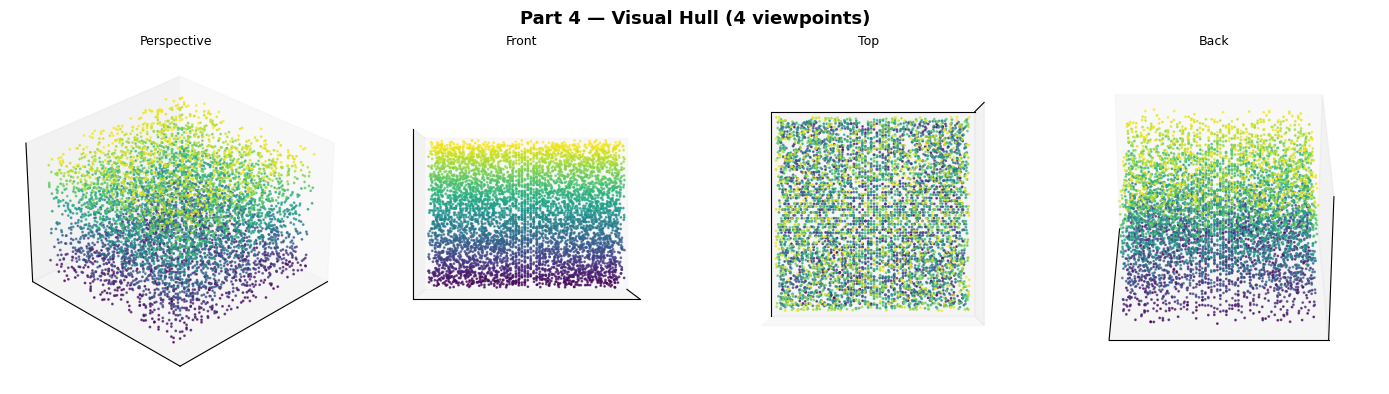

Saved: output/part4_visual_hull.png


In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# Matplotlib 3-D visualization from 4 viewpoints
# ──────────────────────────────────────────────────────────────────────────────
# Subsample for matplotlib speed
n_sub = min(6000, len(hull_pts))
idx_s = np.random.choice(len(hull_pts), n_sub, replace=False)
pts_s = hull_pts[idx_s]

fig = plt.figure(figsize=(14, 4))
fig.suptitle("Part 4 — Visual Hull (4 viewpoints)", fontsize=13, fontweight='bold')

view_angles = [(30, 45, "Perspective"), (0, 0, "Front"),
               (90, 0, "Top"),          (30, 180, "Back")]

for i, (elev, azim, title) in enumerate(view_angles):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    sc = ax.scatter(pts_s[:,0], pts_s[:,2], pts_s[:,1],
                    s=1, c=pts_s[:,1], cmap='viridis', alpha=0.7)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "part4_visual_hull.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/part4_visual_hull.png")

In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# Save as PLY for Open3D / MeshLab viewing
# ──────────────────────────────────────────────────────────────────────────────
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(hull_pts)

# Color by height
y  = hull_pts[:, 1]
yn = (y - y.min()) / (y.max() - y.min() + 1e-8)
colors = plt.cm.viridis(yn)[:, :3]
pcd.colors = o3d.utility.Vector3dVector(colors)

o3d.io.write_point_cloud(str(OUTPUT_DIR / "visual_hull.ply"), pcd)
print("Saved: output/visual_hull.ply")

# Uncomment to view interactively:
# o3d.visualization.draw_geometries([pcd], window_name="Visual Hull")

Saved: output/visual_hull.ply


---
## Part 5 — Mesh Reconstruction (Open3D)

We convert the visual hull point cloud to a surface mesh using two methods:

### Method A — Poisson Surface Reconstruction
Solves a global implicit function (indicator function) using a Poisson equation.
Produces **watertight** meshes; requires good normal estimates. Low-density surface
vertices (boundary artifacts) are pruned.

$$\Delta \chi = \nabla \cdot \vec{V}$$

### Method B — Ball Pivoting Algorithm (BPA)
Rolls a virtual ball of radius $r$ over the point set; a triangle is created wherever
the ball rests on three points without passing through any others. Faster but may
leave holes in sparse regions.

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Estimate normals
# ──────────────────────────────────────────────────────────────────────────────
pcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
)
# Orient consistently outward
pcd.orient_normals_consistent_tangent_plane(k=15)

print(f"Normals estimated for {len(pcd.points)} points.")

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Method A — Poisson Surface Reconstruction
# ──────────────────────────────────────────────────────────────────────────────
print("Running Poisson reconstruction (depth=8)...")
poisson_mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd, depth=8, width=0, scale=1.1, linear_fit=False
)

# Prune low-density vertices (spurious boundary triangles)
dens = np.asarray(densities)
thresh = np.percentile(dens, 10)
poisson_mesh.remove_vertices_by_mask(dens < thresh)
poisson_mesh.compute_vertex_normals()

o3d.io.write_triangle_mesh(str(OUTPUT_DIR / "mesh_poisson.ply"), poisson_mesh)
print(f"Poisson mesh : {len(poisson_mesh.vertices)} verts, "
      f"{len(poisson_mesh.triangles)} tris")
print("Saved: output/mesh_poisson.ply")

# o3d.visualization.draw_geometries([poisson_mesh])

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Method B — Ball Pivoting Algorithm
# ──────────────────────────────────────────────────────────────────────────────
print("Estimating average point spacing for BPA radii...")
tree = o3d.geometry.KDTreeFlann(pcd)
sample_idx = np.random.choice(len(pcd.points), min(300, len(pcd.points)), replace=False)
dists = []
for i in sample_idx:
    _, _, d2 = tree.search_knn_vector_3d(pcd.points[i], 2)
    dists.append(np.sqrt(d2[1]))
avg_d = float(np.mean(dists))
radii = [avg_d, avg_d * 2, avg_d * 4]
print(f"  avg spacing: {avg_d:.4f} | radii: {[round(r,4) for r in radii]}")

bpa_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
    pcd, o3d.utility.DoubleVector(radii)
)
bpa_mesh.compute_vertex_normals()

o3d.io.write_triangle_mesh(str(OUTPUT_DIR / "mesh_bpa.ply"), bpa_mesh)
print(f"BPA mesh  : {len(bpa_mesh.vertices)} verts, "
      f"{len(bpa_mesh.triangles)} tris")
print("Saved: output/mesh_bpa.ply")

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Visualize reconstructed meshes as matplotlib scatter (fallback for headless)
# ──────────────────────────────────────────────────────────────────────────────
def mesh_to_scatter(mesh_o3d, n_sample=4000):
    """Sample points on mesh surface for matplotlib visualization."""
    pcd_s = mesh_o3d.sample_points_uniformly(number_of_points=n_sample)
    pts   = np.asarray(pcd_s.points)
    return pts


fig = plt.figure(figsize=(12, 5))
fig.suptitle("Part 5 — Mesh Reconstruction", fontsize=13, fontweight='bold')

for col, (mesh_r, title) in enumerate(
        [(poisson_mesh, "Poisson"), (bpa_mesh, "Ball Pivoting")]):
    try:
        pts_m = mesh_to_scatter(mesh_r)
        ax = fig.add_subplot(1, 2, col+1, projection='3d')
        ax.scatter(pts_m[:,0], pts_m[:,2], pts_m[:,1],
                   s=1, c=pts_m[:,1], cmap='plasma', alpha=0.7)
        ax.view_init(elev=30, azim=45)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    except Exception as e:
        print(f"{title} mesh visualization failed: {e}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "part5_mesh_reconstruction.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/part5_mesh_reconstruction.png")
print("\nOpen mesh_poisson.ply / mesh_bpa.ply in MeshLab for full 3D viewing.")

---
## Experiments

### Experiment 1 — Effect of Number of Views

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Re-run carving with subsets of cameras
# ──────────────────────────────────────────────────────────────────────────────
view_counts = [5, 10, 20, 30]
hull_sizes  = []
hull_pts_by_views = {}

for nv in view_counts:
    step = max(1, NUM_VIEWS // nv)
    sel  = list(range(0, NUM_VIEWS, step))[:nv]

    occ = np.ones(len(voxel_centers), dtype=bool)
    occ = space_carve(
        voxel_centers, occ,
        silhouettes[sel], R_all[sel], T_all[sel], K, IMG_SIZE
    )
    n_occ = int(occ.sum())
    hull_sizes.append(n_occ)
    hull_pts_by_views[nv] = voxel_centers[occ]
    print(f"Views = {nv:3d}  →  occupied voxels: {n_occ:,}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(view_counts, hull_sizes, 'o-', color='steelblue', lw=2, ms=8)
for x, y in zip(view_counts, hull_sizes):
    ax.annotate(f"{y:,}", (x, y), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=8)
ax.set_xlabel("Number of Views")
ax.set_ylabel("Occupied Voxels")
ax.set_title("View Count vs. Hull Tightness\n(fewer views → larger hull)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp_view_count.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/exp_view_count.png")

### Experiment 2 — Effect of Voxel Resolution

In [ ]:
resolutions = [16, 32, 64]
res_sizes   = []

for res in resolutions:
    ax_r = np.linspace(-GRID_RANGE, GRID_RANGE, res)
    gx_r, gy_r, gz_r = np.meshgrid(ax_r, ax_r, ax_r, indexing='ij')
    vc_r  = np.stack([gx_r, gy_r, gz_r], axis=-1).reshape(-1, 3)
    occ_r = np.ones(len(vc_r), dtype=bool)

    occ_r = space_carve(vc_r, occ_r, silhouettes, R_all, T_all, K, IMG_SIZE)
    n = int(occ_r.sum())
    res_sizes.append(n)
    print(f"Resolution = {res:3d}³  →  occupied: {n:,} / {len(vc_r):,}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([str(r) for r in resolutions], res_sizes,
              color=['#5B8DB8','#3A6F9A','#1E4D7B'])
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xlabel("Voxel Resolution (per axis)")
ax.set_ylabel("Occupied Voxels")
ax.set_title("Voxel Resolution vs. Hull Size")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp_resolution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/exp_resolution.png")

---
## Analysis & Discussion

### Reconstruction Limitations

**1. Missing Concavities**  
The visual hull is a *conservative* upper bound — it cannot recover concave geometry.
Any concave region is silhouette-consistent from all views (a dented sphere looks like a
full sphere in projection). This is a fundamental theoretical limitation.

**2. Effect of View Count**  
Fewer views produce a looser (larger) hull because fewer silhouette constraints are
applied. More views tighten the hull, but with diminishing returns above ~20 well-distributed views.
Coverage (spanning all azimuths and elevations) matters more than raw count.

**3. Voxel Resolution**  
Higher resolution captures finer surface detail but costs $O(G^3)$ memory and time.
At $64^3$ the pipeline runs in seconds on CPU; at $128^3$ consider batched processing.

**4. Silhouette Quality**  
Blurry or noisy silhouettes cause mis-classification at the boundary. The binary threshold
at the silhouette edge is a trade-off: too strict → under-carving (hull too large); too
loose → over-carving (surface holes).

**5. Camera Consistency**  
The rendering convention and projection function must use the **same** coordinate system.
The projection verification overlay in Part 2 is the key sanity check.

### Poisson vs. Ball Pivoting

| Property | Poisson | Ball Pivoting |
|---|---|---|
| Watertight output | ✅ Always | ❌ May have holes |
| Noise robustness | ✅ Implicit smoothing | ❌ Sensitive to outliers |
| Normal dependency | High | Medium |
| Speed | Slower | Faster |
| Detail preservation | Smoothed | Sharper edges |

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Summary figure — all deliverables in one plot
# ──────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle("CSE5280 — Visual Hull Reconstruction Summary",
             fontsize=15, fontweight='bold')

gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.3)

# Row 1: 5 sample RGB views with silhouette overlay
for i in range(5):
    idx = i * (NUM_VIEWS // 5)
    ax  = fig.add_subplot(gs[0, i])
    ax.imshow(rgb_images[idx])
    sil_overlay = np.zeros((*silhouettes[idx].shape, 4))
    sil_overlay[silhouettes[idx]] = [1, 0.3, 0.3, 0.4]
    ax.imshow(sil_overlay)
    ax.set_title(f"View {idx}", fontsize=8)
    ax.axis('off')

# Row 2: visual hull from 4 angles + experiment chart
for i, (elev, azim, ttl) in enumerate(
        [(30, 45, "Perspective"), (0, 0, "Front"),
         (90, 0, "Top"), (30, 180, "Back")]):
    ax = fig.add_subplot(gs[1, i], projection='3d')
    ax.scatter(pts_s[:,0], pts_s[:,2], pts_s[:,1],
               s=1, c=pts_s[:,1], cmap='plasma', alpha=0.7)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(ttl, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

ax_exp = fig.add_subplot(gs[1, 4])
ax_exp.plot(view_counts, hull_sizes, 'o-', color='tomato', lw=2)
ax_exp.set_xlabel("# Views", fontsize=8)
ax_exp.set_ylabel("Occupied Voxels", fontsize=8)
ax_exp.set_title("Hull Size vs. Views", fontsize=9)
ax_exp.grid(True, alpha=0.3)

plt.savefig(OUTPUT_DIR / "summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/summary.png")
print("\n=== All 5 parts complete ===")
print(f"\nOutput files in '{OUTPUT_DIR.resolve()}':\n")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")